In [ ]:
import pandas as pd
from sklearn.utils import resample
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, f1_score, roc_curve, auc, precision_score, recall_score, make_scorer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier
import time
import hashlib
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Mini/new1.csv')

In [ ]:
print(df)

In [ ]:
majority_class = df[df['Class'] == 0]
minority_class = df[df['Class'] == 1]

In [ ]:
target_minority_size = len(majority_class)
minority_oversampled = resample(
    minority_class,
    replace=True,
    n_samples=target_minority_size,
    random_state=42
)
data_balanced = pd.concat([majority_class, minority_oversampled])
data_balanced = data_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

In [ ]:
def hash_feature(value):
    if pd.notnull(value):
        return int(hashlib.sha256(str(value).encode()).hexdigest(), 16) % 10**8
    return 0

In [ ]:
data_balanced['From'] = data_balanced['From'].apply(hash_feature)
data_balanced['To'] = data_balanced['To'].apply(hash_feature)
data_balanced['TxHash'] = data_balanced['TxHash'].apply(hash_feature)
data_balanced['Input'] = data_balanced['Input'].apply(hash_feature)
data_balanced['ContractAddress'] = data_balanced['ContractAddress'].apply(hash_feature)

In [ ]:
numerical_features = ['BlockHeight', 'Value', 'From', 'To', 'TxHash']
scaler = MinMaxScaler(feature_range=(0, 1))
data_balanced[numerical_features] = scaler.fit_transform(data_balanced[numerical_features])

In [ ]:
X = data_balanced.drop(columns=['Class'])
y = data_balanced['Class']
X = X.fillna(0)
selector = SelectKBest(score_func=f_classif, k=5)
X_new = selector.fit_transform(X, y)
selected_features = X.columns[selector.get_support(indices=True)]
print("Selected Features:", selected_features)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_new, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
classifiers = {}
classifiers["JRip (Logistic Regression Approximation)"] = GradientBoostingClassifier(n_estimators=100, random_state=42)


In [ ]:
classifiers["Naive-Bayes Tree"] = RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42)


In [ ]:
classifiers["OneR (Simplified Rule-Based)"] = RandomForestClassifier(n_estimators=100, random_state=42)


In [ ]:
classifiers["Fast Decision Tree"] = GradientBoostingClassifier(n_estimators=100, random_state=42)


In [ ]:
classifiers = {
    "J48 Decision Tree": DecisionTreeClassifier(criterion="entropy", random_state=42),
    "C4.5 Decision Tree": DecisionTreeClassifier(criterion="gini", random_state=42),
    "JRip (Logistic Regression Approximation)": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "Naive-Bayes Tree": RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42),
    "OneR (Simplified Rule-Based)": RandomForestClassifier(n_estimators=100, random_state=42),
    "PART Decision List (Random Forest)": RandomForestClassifier(n_estimators=10, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=3, weights='distance', metric='minkowski', p=2),
    "Random Forest": RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
}


In [ ]:
for name, clf in classifiers.items():
    start_time = time.time()
    clf.fit(X_train, y_train)
    elapsed_time = time.time() - start_time
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    print(f"\n{name} Supplied Set Test Accuracy: {acc}")
    print(f"{name} Supplied Set Test Classification Report:\n", classification_report(y_test, y_pred))
    print(f"{name} Time Taken to Build Model: {elapsed_time:.4f} seconds")


    if name == "KNN":
        neighbors_proba = []
        for instance in X_test:
            distances, indices = clf.kneighbors([instance])
            prob = sum(y_train.iloc[indices[0]]) / len(indices[0])
            neighbors_proba.append(prob)
        y_prob = pd.Series(neighbors_proba)
    elif hasattr(clf, "predict_proba"):
        y_prob = clf.predict_proba(X_test)[:, 1]
    else:
        y_prob = clf.decision_function(X_test)


    if name == "KNN" or hasattr(clf, "predict_proba"):
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_auc = auc(fpr, tpr)
        print(f"{name} ROC AUC: {roc_auc:.4f}")
        print(f"{name} False Positive Rate (fpr): {fpr}")


        plt.figure()
        plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'Receiver Operating Characteristic - {name}')
        plt.legend(loc="lower right")
        plt.show()

In [ ]:
import time
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, accuracy_score

def fast_decision_tree(X_train, X_test, y_train, y_test):
    parameters = {'max_depth': [10, 20, 30, None], 'min_samples_leaf': [1, 2, 4], 'min_samples_split': [2, 5, 10]}
    clf = GridSearchCV(DecisionTreeClassifier(), parameters, cv=5)


    start_time = time.time()

    clf.fit(X_train, y_train)
    best_clf = clf.best_estimator_
    y_pred = best_clf.predict(X_test)


    elapsed_time = time.time() - start_time

    print(f"Fast Decision Tree Accuracy: {accuracy_score(y_test, y_pred)}")


    fpr, tpr, _ = roc_curve(y_test, best_clf.predict_proba(X_test)[:, 1])
    roc_auc = auc(fpr, tpr)

    print(f"FPR: {fpr}")
    print(f"ROC AUC: {roc_auc:.2f}")

    print(f"Classification Report:\n{classification_report(y_test, y_pred)}")


    print(f"Time Taken to Build Model: {elapsed_time:.4f} seconds")

    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC)')
    plt.legend(loc='lower right')
    plt.show()

    return best_clf

fast_decision_tree(X_train, X_test, y_train, y_test)


J48 Decision Tree Cross-Validation F1 Scores: [0.98571702 0.98445386 0.98705896 0.98792722 0.98666428 0.98729478
 0.98634746 0.98524217 0.98642641 0.98579483]
J48 Decision Tree Mean F1 Score: 0.9862927005501227
J48 Decision Tree Test Accuracy: 0.9876
J48 Decision Tree ROC AUC: 0.9878
J48 Decision Tree False Positive Rate (FPR):
[0.         0.02417319 0.02417319 0.02417319 0.0242363  0.0242363
 0.0242363  0.0242363  0.02429942 0.02436253 0.02442565 0.02448877
 0.02455188 0.02455188 0.024615   0.024615   0.02467811 0.02467811
 0.02467811 0.02480434 0.02480434 1.        ]
J48 Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     15844
           1       0.98      1.00      0.99     15843

    accuracy                           0.99     31687
   macro avg       0.99      0.99      0.99     31687
weighted avg       0.99      0.99      0.99     31687

J48 Decision Tree Time Taken to Build Model: 0.7597 seco

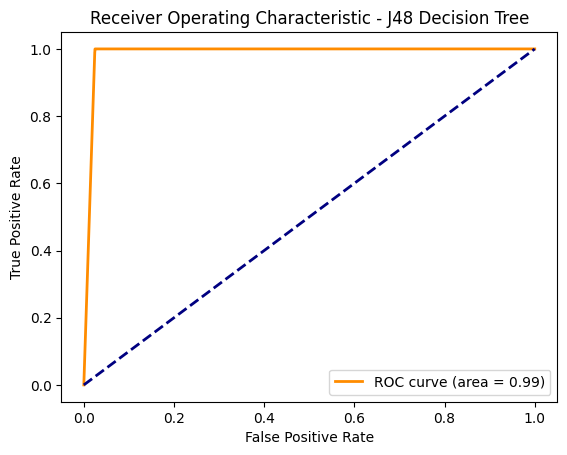

C4.5 Decision Tree Cross-Validation F1 Scores: [0.98666431 0.9853223  0.98792722 0.98808508 0.98658534 0.98721584
 0.98705796 0.98571588 0.98618957 0.98492635]
C4.5 Decision Tree Mean F1 Score: 0.9865689860597783
C4.5 Decision Tree Test Accuracy: 0.9869
C4.5 Decision Tree ROC AUC: 0.9870
C4.5 Decision Tree False Positive Rate (FPR):
[0.         0.02562484 0.02562484 0.02562484 0.02562484 0.02562484
 0.02562484 0.02568796 0.02568796 0.02568796 0.02575107 0.02581419
 0.0258773  0.0258773  0.02594042 0.02594042 0.02600353 0.02600353
 0.02600353 0.02612977 0.02612977 1.        ]
C4.5 Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     15844
           1       0.97      1.00      0.99     15843

    accuracy                           0.99     31687
   macro avg       0.99      0.99      0.99     31687
weighted avg       0.99      0.99      0.99     31687

C4.5 Decision Tree Time Taken to Build Model: 0.6

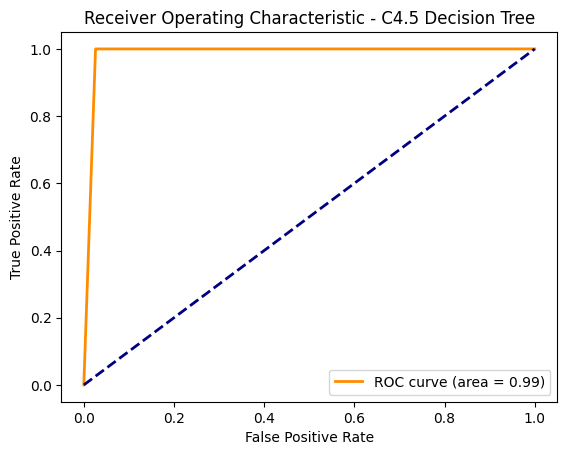

JRip (Logistic Regression Approximation) Cross-Validation F1 Scores: [0.86291822 0.86996096 0.86992907 0.86745116 0.86748838 0.87571532
 0.86970674 0.86772783 0.86993154 0.86782681]
JRip (Logistic Regression Approximation) Mean F1 Score: 0.8688656022743272
JRip (Logistic Regression Approximation) Test Accuracy: 0.8673
JRip (Logistic Regression Approximation) ROC AUC: 0.9496
JRip (Logistic Regression Approximation) False Positive Rate (FPR):
[0.00000000e+00 0.00000000e+00 6.31153749e-05 ... 9.99810654e-01
 9.99873769e-01 1.00000000e+00]
JRip (Logistic Regression Approximation) Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87     15844
           1       0.88      0.85      0.86     15843

    accuracy                           0.87     31687
   macro avg       0.87      0.87      0.87     31687
weighted avg       0.87      0.87      0.87     31687

JRip (Logistic Regression Approximation) Time Taken to Build Model:

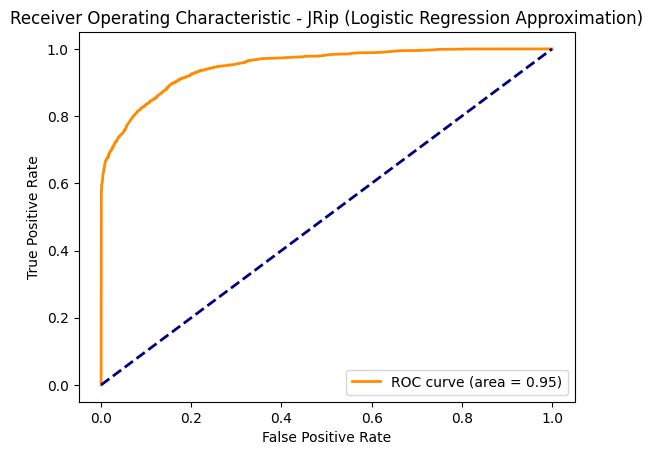

Naive-Bayes Tree Cross-Validation F1 Scores: [0.98950576 0.98942683 0.99124193 0.99163649 0.99195214 0.99013633
 0.99139908 0.98934706 0.98982063 0.98926813]
Naive-Bayes Tree Mean F1 Score: 0.9903734379112038
Naive-Bayes Tree Test Accuracy: 0.9908
Naive-Bayes Tree ROC AUC: 0.9976
Naive-Bayes Tree False Positive Rate (FPR):
[0.         0.00467054 0.00479677 0.00479677 0.00517546 0.00517546
 0.00536481 0.00549104 0.00549104 0.00549104 0.00549104 0.00549104
 0.0057435  0.00580661 0.00580661 0.00593285 0.00593285 0.00593285
 0.00593285 0.00593285 0.00593285 0.00593285 0.00593285 0.00593285
 0.00593285 0.00612219 0.00612219 0.00612219 0.00612219 0.00612219
 0.00612219 0.00612219 0.00612219 0.00612219 0.00612219 0.00612219
 0.00612219 0.00612219 0.00618531 0.00618531 0.00618531 0.00618531
 0.00618531 0.00637465 0.00637465 0.00637465 0.00637465 0.00637465
 0.00637465 0.00637465 0.00662711 0.00662711 0.00662711 0.00662711
 0.00662711 0.00669023 0.00681646 0.00681646 0.00706892 0.00706892
 0.00

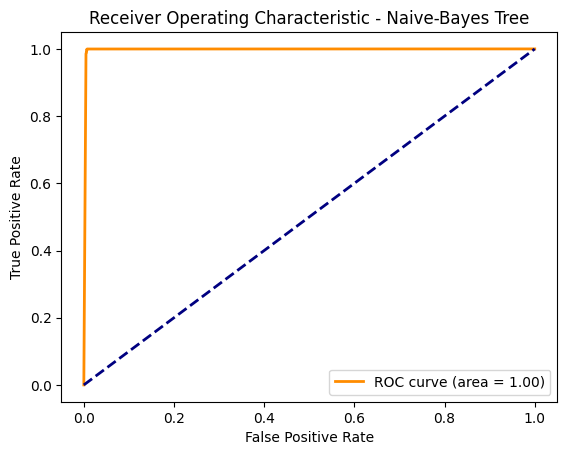

OneR (Simplified Rule-Based) Cross-Validation F1 Scores: [0.98982144 0.98919007 0.99124193 0.99163649 0.99195214 0.98997848
 0.99092556 0.98966277 0.98989955 0.98926813]
OneR (Simplified Rule-Based) Mean F1 Score: 0.9903576560265102
OneR (Simplified Rule-Based) Test Accuracy: 0.9910
OneR (Simplified Rule-Based) ROC AUC: 0.9977
OneR (Simplified Rule-Based) False Positive Rate (FPR):
[0.         0.00448119 0.004923   0.004923   0.00530169 0.00530169
 0.00542792 0.00568038 0.00568038 0.00568038 0.00568038 0.00568038
 0.00580661 0.00580661 0.00605908 0.00605908 0.00605908 0.00605908
 0.00605908 0.00605908 0.00605908 0.00605908 0.00605908 0.00605908
 0.00612219 0.00612219 0.00612219 0.00612219 0.00612219 0.00612219
 0.00612219 0.00612219 0.00612219 0.00631154 0.00631154 0.00631154
 0.00631154 0.00631154 0.00631154 0.00631154 0.00631154 0.00631154
 0.00637465 0.00637465 0.00637465 0.00637465 0.00643777 0.00643777
 0.00643777 0.00643777 0.006564   0.006564   0.006564   0.006564
 0.006564   0.

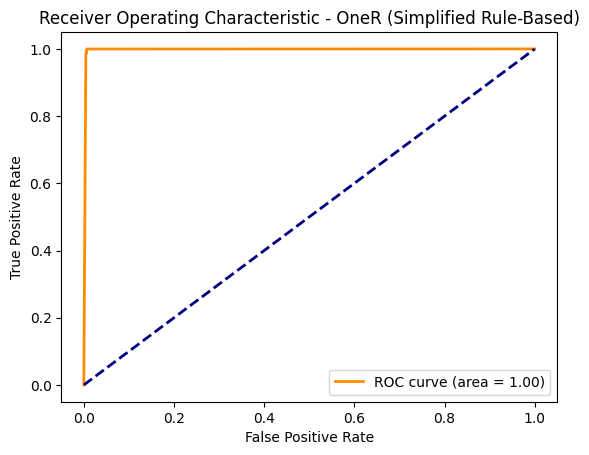

PART Decision List (Random Forest) Cross-Validation F1 Scores: [0.99029495 0.98919007 0.99116301 0.99076844 0.99100518 0.98997848
 0.99139908 0.98982063 0.99029418 0.98918921]
PART Decision List (Random Forest) Mean F1 Score: 0.9903103222198771
PART Decision List (Random Forest) Test Accuracy: 0.9908
PART Decision List (Random Forest) ROC AUC: 0.9964
PART Decision List (Random Forest) False Positive Rate (FPR):
[0.         0.00706892 0.00706892 0.00706892 0.00706892 0.00706892
 0.00706892 0.00706892 0.00706892 0.00706892 0.00706892 0.00706892
 0.00706892 0.00706892 0.00706892 0.00706892 0.00706892 0.00706892
 0.00706892 0.00706892 0.00706892 0.00713204 0.00713204 0.00713204
 0.00713204 0.00713204 0.00713204 0.00713204 0.00713204 0.00713204
 0.00713204 0.00713204 0.00713204 0.00713204 0.00713204 0.00713204
 0.00870992 0.00870992 0.00870992 0.00877304 0.00877304 0.00883615
 0.00883615 0.00883615 0.00883615 0.00896238 0.00896238 0.00896238
 0.00896238 0.00896238 0.01104519 0.01117142 0.01

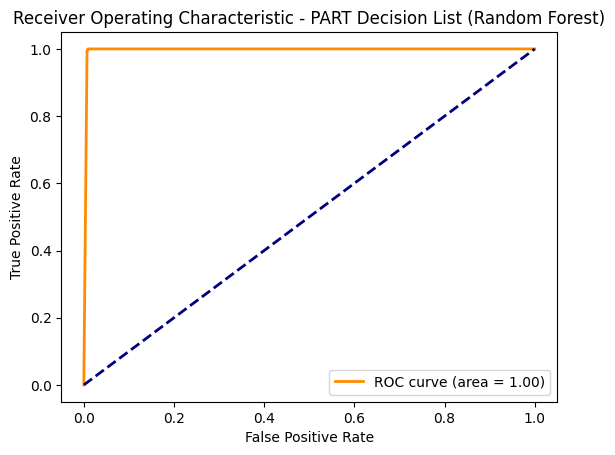

KNN Cross-Validation F1 Scores: [0.98026849 0.97576547 0.97916293 0.98090065 0.9788468  0.97797576
 0.9790029  0.97916091 0.97860786 0.97726457]
KNN Mean F1 Score: 0.9786956349286143
KNN Test Accuracy: 0.9804
KNN ROC AUC: 0.9868
KNN False Positive Rate (FPR):
[0.         0.02619288 0.04620045 0.06481949 1.        ]
KNN Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.96      0.98     15844
           1       0.96      1.00      0.98     15843

    accuracy                           0.98     31687
   macro avg       0.98      0.98      0.98     31687
weighted avg       0.98      0.98      0.98     31687

KNN Time Taken to Build Model: 0.1308 seconds


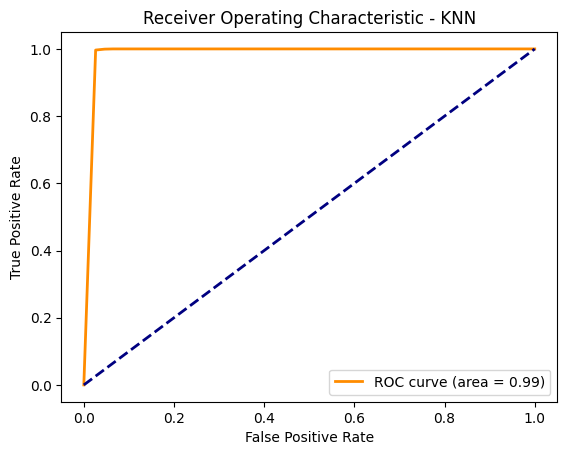

Random Forest Cross-Validation F1 Scores: [0.98950576 0.98942683 0.99124193 0.99163649 0.99195214 0.99013633
 0.99139908 0.98934706 0.98982063 0.98926813]
Random Forest Mean F1 Score: 0.9903734379112038
Random Forest Test Accuracy: 0.9908
Random Forest ROC AUC: 0.9976
Random Forest False Positive Rate (FPR):
[0.         0.00467054 0.00479677 0.00479677 0.00517546 0.00517546
 0.00536481 0.00549104 0.00549104 0.00549104 0.00549104 0.00549104
 0.0057435  0.00580661 0.00580661 0.00593285 0.00593285 0.00593285
 0.00593285 0.00593285 0.00593285 0.00593285 0.00593285 0.00593285
 0.00593285 0.00612219 0.00612219 0.00612219 0.00612219 0.00612219
 0.00612219 0.00612219 0.00612219 0.00612219 0.00612219 0.00612219
 0.00612219 0.00612219 0.00618531 0.00618531 0.00618531 0.00618531
 0.00618531 0.00637465 0.00637465 0.00637465 0.00637465 0.00637465
 0.00637465 0.00637465 0.00662711 0.00662711 0.00662711 0.00662711
 0.00662711 0.00669023 0.00681646 0.00681646 0.00706892 0.00706892
 0.00713204 0.007132

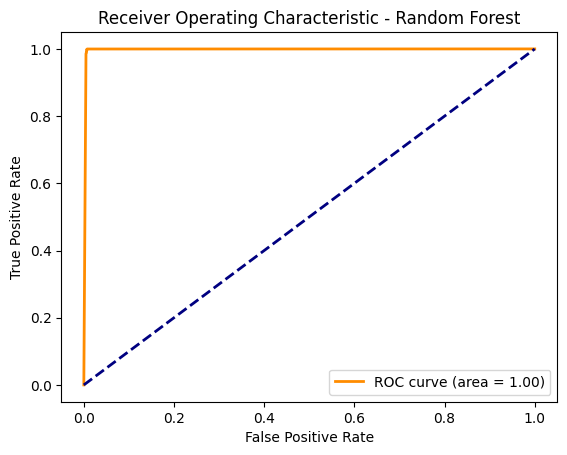

In [ ]:
import time
from sklearn.metrics import classification_report, accuracy_score, roc_curve, auc
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import make_scorer, f1_score
from sklearn.model_selection import cross_val_score

f1_scorer = make_scorer(f1_score, average='weighted')
results = {}

for name, clf in classifiers.items():
    f1_scores = cross_val_score(clf, X_train, y_train, cv=10, scoring=f1_scorer)
    results[name] = {
        "F1 Scores": f1_scores,
        "Mean F1 Score": f1_scores.mean()
    }

    print(f"{name} Cross-Validation F1 Scores:", f1_scores)
    print(f"{name} Mean F1 Score:", f1_scores.mean())

    start_time = time.time()
    clf.fit(X_train, y_train)
    elapsed_time = time.time() - start_time
    y_pred = clf.predict(X_test)


    accuracy = accuracy_score(y_test, y_pred)
    print(f"{name} Test Accuracy: {accuracy:.4f}")

    if name == "KNN":
        neighbors_proba = []
        for instance in X_test:
            distances, indices = clf.kneighbors([instance])
            prob = sum(y_train.iloc[indices[0]]) / len(indices[0])
            neighbors_proba.append(prob)
        y_prob = pd.Series(neighbors_proba)
    elif hasattr(clf, "predict_proba"):
        y_prob = clf.predict_proba(X_test)[:, 1]
    else:
        y_prob = clf.decision_function(X_test)

    if name == "KNN" or hasattr(clf, "predict_proba"):

        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_auc = auc(fpr, tpr)

        print(f"{name} ROC AUC: {roc_auc:.4f}")
        print(f"{name} False Positive Rate (FPR):")
        print(fpr)


    print(f"{name} Classification Report:")
    print(classification_report(y_test, y_pred))


    print(f"{name} Time Taken to Build Model: {elapsed_time:.4f} seconds")

    if name == "KNN" or hasattr(clf, "predict_proba"):

        plt.figure()
        plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'Receiver Operating Characteristic - {name}')
        plt.legend(loc="lower right")
        plt.show()



Fast Decision Tree Test Accuracy: 0.9995
ROC AUC: 0.9849
False Positive Rate (FPR):
[0.         0.0299028  0.0299028  0.0299028  0.0299028  0.0299028
 0.02991858 0.02991858 0.02991858 0.02991858 0.02991858 0.02991858
 0.02991858 0.02991858 0.02995014 0.02995014 0.02995014 0.02995014
 0.02999748 0.03007637 0.03018683 0.03023417 0.03026573 0.03029729
 0.03032885 0.03034463 0.03040775 0.03043931 0.03043931 0.03053399
 0.03058133 0.03061289 1.        ]
Fast Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     63372
           1       1.00      1.00      1.00     63373

    accuracy                           1.00    126745
   macro avg       1.00      1.00      1.00    126745
weighted avg       1.00      1.00      1.00    126745

Time Taken to Build Model: 0.0177 seconds


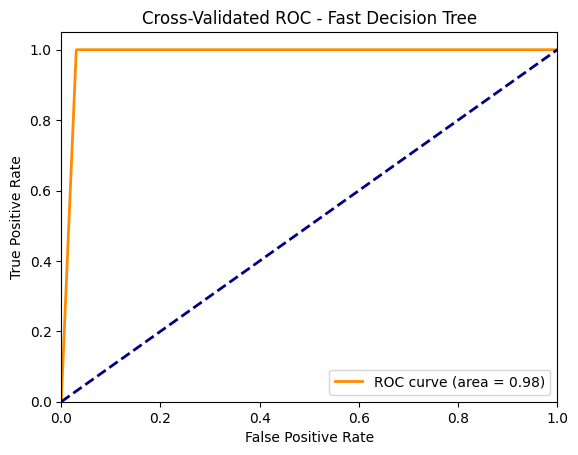

Best Estimator: DecisionTreeClassifier(min_samples_split=5)


In [ ]:
from sklearn.model_selection import GridSearchCV, cross_val_predict
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc
import matplotlib.pyplot as plt
import time

def fast_decision_tree_with_cv(X, y, cv=5):
    parameters = {'max_depth': [10, 20, 30, None], 'min_samples_leaf': [1, 2, 4], 'min_samples_split': [2, 5, 10]}
    clf = GridSearchCV(DecisionTreeClassifier(), parameters, cv=cv)
    clf.fit(X, y)
    best_clf = clf.best_estimator_

    start_time = time.time()
    y_pred = best_clf.predict(X)
    elapsed_time = time.time() - start_time

    accuracy = accuracy_score(y, y_pred)
    print(f"Fast Decision Tree Test Accuracy: {accuracy:.4f}")


    y_prob_cv = cross_val_predict(best_clf, X, y, cv=cv, method='predict_proba')[:, 1]


    fpr, tpr, thresholds = roc_curve(y, y_prob_cv)
    roc_auc = auc(fpr, tpr)


    print(f"ROC AUC: {roc_auc:.4f}")
    print("False Positive Rate (FPR):")
    print(fpr)


    print("Fast Decision Tree Classification Report:")
    print(classification_report(y, y_pred))

    print(f"Time Taken to Build Model: {elapsed_time:.4f} seconds")

    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Cross-Validated ROC - Fast Decision Tree')
    plt.legend(loc="lower right")
    plt.show()

    print(f"Best Estimator: {best_clf}")

    return best_clf

best_clf = fast_decision_tree_with_cv(X_train, y_train, cv=5)

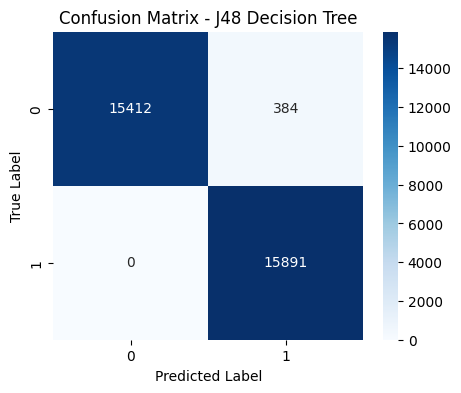

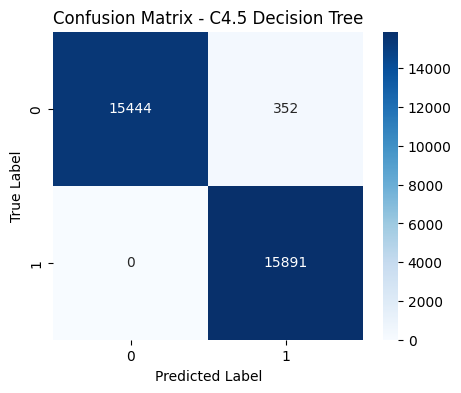

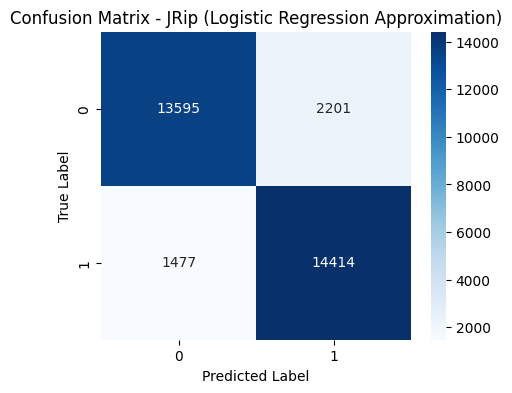

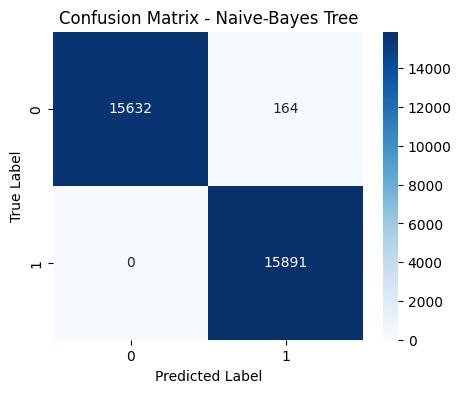

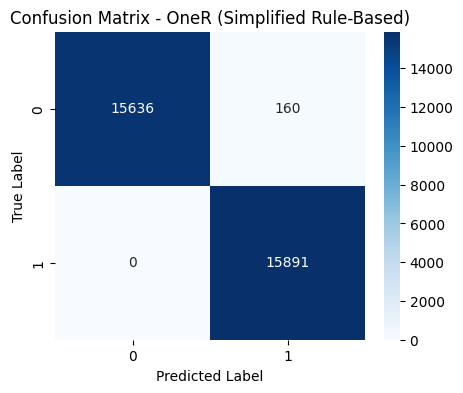

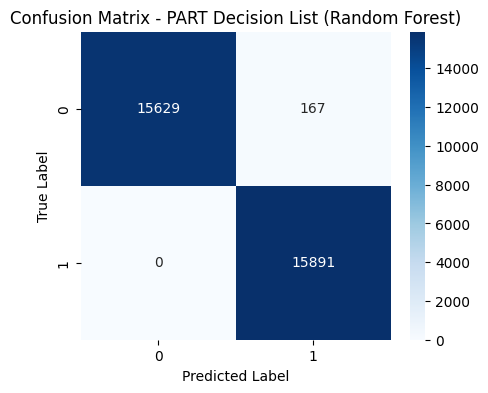

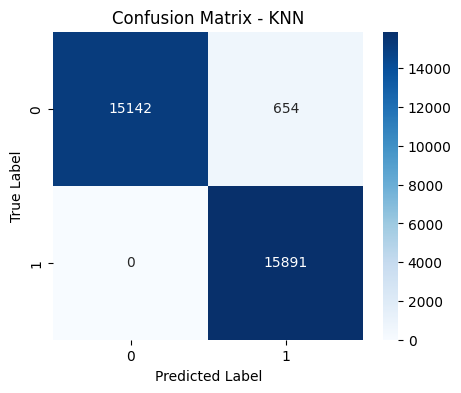

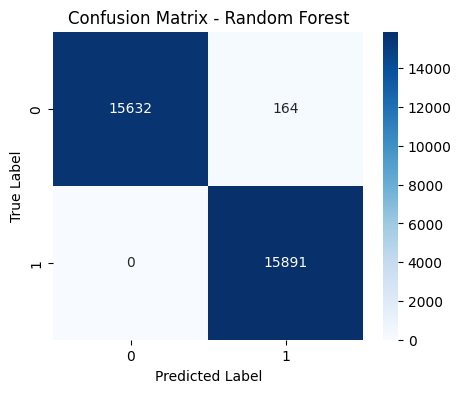

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.model_selection import train_test_split

# Train-test split (ensure X and y are defined in your dataset)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

for name, clf in classifiers.items():
    # Train model
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()


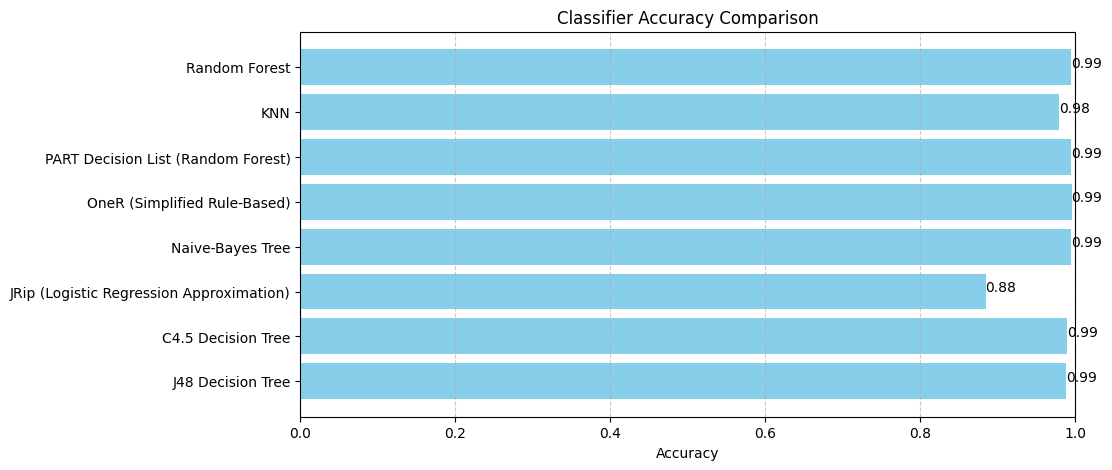

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score

accuracy_results = {}

for name, clf in classifiers.items():
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    accuracy_results[name] = accuracy

# Plot accuracy for all models
plt.figure(figsize=(10, 5))
plt.barh(list(accuracy_results.keys()), list(accuracy_results.values()), color='skyblue')
plt.xlabel("Accuracy")
plt.title("Classifier Accuracy Comparison")
plt.xlim(0, 1)  # Accuracy ranges from 0 to 1
plt.grid(axis="x", linestyle="--", alpha=0.7)

# Show accuracy values on bars
for index, value in enumerate(accuracy_results.values()):
    plt.text(value, index, f"{value:.2f}")

plt.show()


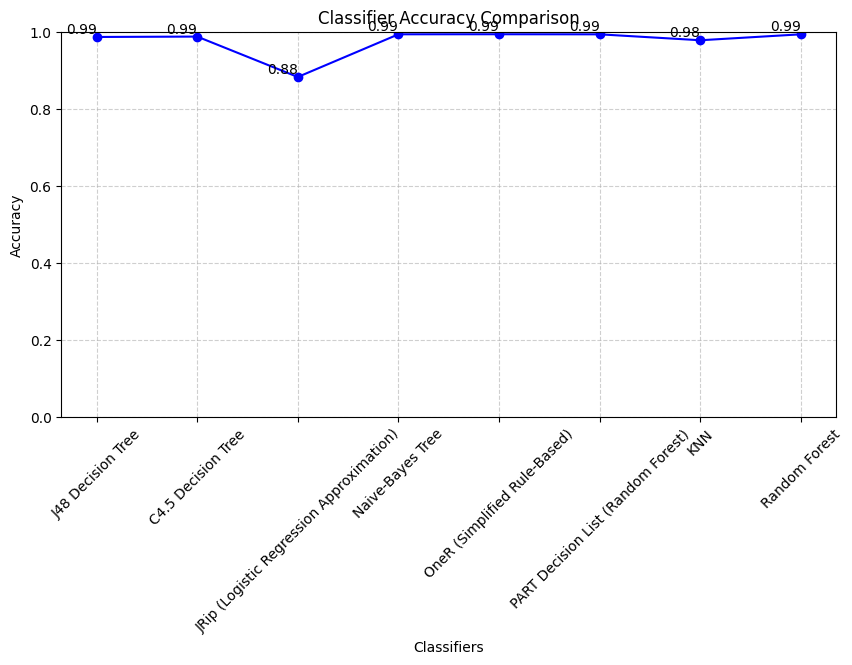

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

accuracy_results = {}

for name, clf in classifiers.items():
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    accuracy_results[name] = accuracy

# Plot accuracy for all models using a line plot
plt.figure(figsize=(10, 5))
plt.plot(list(accuracy_results.keys()), list(accuracy_results.values()), marker='o', linestyle='-', color='b')

plt.xlabel("Classifiers")
plt.ylabel("Accuracy")
plt.title("Classifier Accuracy Comparison")
plt.ylim(0, 1)  # Accuracy ranges from 0 to 1
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.6)

# Show accuracy values on points
for i, value in enumerate(accuracy_results.values()):
    plt.text(i, value, f"{value:.2f}", ha="right", va="bottom")

plt.show()


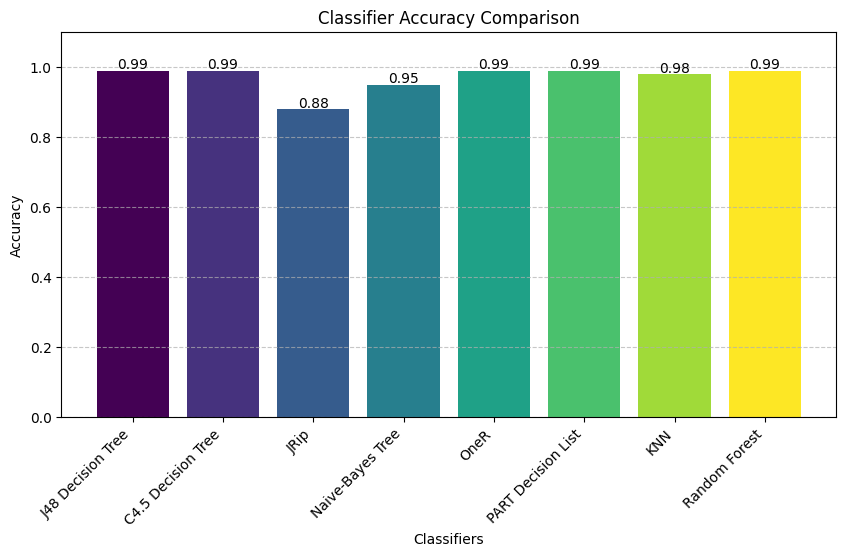

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Sample classifier accuracy results (replace with actual values)
accuracy_results = {
    "J48 Decision Tree": 0.99,
    "C4.5 Decision Tree": 0.99,
    "JRip": 0.88,
    "Naive-Bayes Tree": 0.95,
    "OneR": 0.99,
    "PART Decision List": 0.99,
    "KNN": 0.98,
    "Random Forest": 0.99
}

# Bar plot
plt.figure(figsize=(10, 5))
colors = plt.cm.viridis(np.linspace(0, 1, len(accuracy_results)))

plt.bar(accuracy_results.keys(), accuracy_results.values(), color=colors)

# Labels and title
plt.xlabel("Classifiers")
plt.ylabel("Accuracy")
plt.title("Classifier Accuracy Comparison")
plt.xticks(rotation=45, ha='right')

# Show accuracy values on bars
for i, (name, value) in enumerate(accuracy_results.items()):
    plt.text(i, value + 0.005, f"{value:.2f}", ha="center", fontsize=10)

plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle="--", alpha=0.7)

plt.show()
